# Self-consistency CLUTRR FDR-gate calibration diagonal (decoy self-report disconfirmation)

This demo reproduces the **single primary artifact** of the experiment: a per-family
*realized-FDR-vs-target-α* **calibration diagonal** for a label-free
**decoy-competition (knockoff+) FDR gate** that decides which LLM-extracted CLUTRR
kinship facts are admitted into a symbolic (Prolog-style) layer.

The gate is part of a neuro-symbolic text→logic pipeline: an LLM extracts candidate
facts `(head, relation, tail)` from a short document, each candidate is scored, and a
**knockoff+** competition against a *counterfactual decoy* of the same fact decides
admission at a target false-discovery rate α — **with no gold labels at inference time**.

**What this notebook shows (no API calls needed):** starting from the experiment's
**pre-computed K=5 self-consistency scores** (real score, matched counterfactual-decoy
score, in-doc swap-decoy score, raw confidence) and the **crisp CLUTRR gold labels**, we
re-run the offline statistical core to obtain, side-by-side:

| arm | what it is |
|-----|------------|
| **METHOD** | counterfactual-decoy **knockoff+** gate (the headline) |
| **BASELINE** | **plain raw-confidence** threshold gate (the purely-neural foil) |
| **CONTROL** | random in-doc **swap-decoy** knockoff (anti-conservative negative control) |

Then we run the **crux** test (are decoys distributionally exchangeable with genuine
errors yet distinct from true positives?) and emit the pre-registered
**primary-disconfirmation verdict**.

**Headline (full ~593-doc run):** on the error-dense `multi_hop` family the gate is
**DISCONFIRMED** at the tightest certified α\* = 0.5 — realized FDR ≈ 1.0 with the
doc-block CI entirely above α\*, while the gate's own `decoy_fdr_hat` self-reports only
0.5 (anti-conservative). This demo runs on a curated **100-example** subset and
reproduces that qualitative result.


## Setup — install dependencies

The statistical core only needs `numpy`, `scipy`, and `matplotlib` (all pre-installed on
Colab). On Colab we use Colab's versions; locally we pin Colab's exact versions so the
environment matches.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / scipy / matplotlib are pre-installed on Colab — install locally only, at
# Colab's exact versions (installing them ON Colab corrupts the loaded C extensions).
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

The original experiment imports `numpy` and `scipy.stats`; we add `matplotlib` for the
final visualization. (The numpy-2.0 compat shims are harmless no-ops on Colab's numpy 2.0.)

In [2]:
import json, os, math, hashlib
from typing import Callable, Sequence

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# numpy 2.0 removed a few long-deprecated aliases; restore them defensively.
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "sometrue"): np.sometrue = np.any
if not hasattr(np, "product"): np.product = np.prod

# crisp CLUTRR gold label constants (from fdr_core.py)
TRUE, FALSE = "TRUE", "FALSE"
print("imports ok — numpy", np.__version__, "| scipy", stats.__name__)

imports ok — numpy 2.0.2 | scipy scipy.stats


## Data loading

`mini_demo_data.json` is a curated, stratified **100-example** subset of the experiment's
output (`full_method_out.json`). Each example carries the pre-computed self-consistency
scores and the crisp gold label, so the whole diagonal is reproducible offline.

We load from the GitHub raw URL with a local-file fallback (works in Colab now and after
deployment).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-3/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["examples"]
print("dataset:", data["dataset"])
print("n examples:", len(examples))
print("example fields:", list(examples[0].keys()))
print("\nsample example input:", examples[0]["input"])
print("sample example output (gold):", examples[0]["output"])

dataset: CLUTRR-v1-CrispGold-CalibrationAnchor
n examples: 100
example fields: ['input', 'output', 'metadata_doc_id', 'metadata_fact_type', 'metadata_chain_length_k', 'metadata_is_pilot', 'metadata_decoy_relation', 'metadata_swap_tail', 'metadata_z_real_raw_sc', 'metadata_z_real_sc', 'metadata_z_decoy_sc', 'metadata_z_swap_sc', 'metadata_w_cf_sc', 'metadata_w_swap_sc', 'metadata_z_real_raw_vb', 'metadata_z_real_vb', 'metadata_w_cf_vb', 'predict_admit_sc_a05', 'predict_admit_sc_a10', 'predict_admit_sc_a20', 'predict_admit_sc_a30', 'predict_admit_sc_a50']

sample example input: {"doc_id": "06b7bcc8-d304-428b-ac49-a4c5a18548f9", "head": "Christian", "relation": "father", "tail": "Darren", "claim": "Darren is the father of Christian.", "candidate_kind": "real"}
sample example output (gold): FALSE


## Config — all tunable parameters

These mirror the experiment's constants. The only DEMO-scale changes are:
- `B_BOOT` — number of document-block bootstrap resamples (the **original 2000**; this
  step is cheap, so the demo keeps the full value. Lower it for an even faster run.).
- `N_FALSE_MIN` — minimum genuine-FALSE candidates for a family to be "populable"
  (original **40**, sized for the full ~593-doc corpus; lowered here to suit the 100-example
  subset).

In [5]:
SEED        = 20240617
ALPHA_GRID  = [0.05, 0.10, 0.20, 0.30, 0.50]   # target FDR levels; k-floors {20,10,5,4,2}
TAU         = 0.05                              # tolerance band for the disconfirmation test
B_BOOT      = 2000                             # doc-block bootstrap resamples (original value)
N_FALSE_MIN = 20                               # populability floor for the demo (original: 40)
FAMILIES    = ["atomic", "multi_hop", "pooled"]
print("config:", dict(SEED=SEED, ALPHA_GRID=ALPHA_GRID, TAU=TAU, B_BOOT=B_BOOT,
                       N_FALSE_MIN=N_FALSE_MIN))

config: {'SEED': 20240617, 'ALPHA_GRID': [0.05, 0.1, 0.2, 0.3, 0.5], 'TAU': 0.05, 'B_BOOT': 2000, 'N_FALSE_MIN': 20}


## The offline statistical core

These functions are copied **verbatim** from the experiment's unit-tested `fdr_stats.py`
(the pure, API-free core). They implement:
- the canonical **signed-max** knockoff statistic `W_i = sign(Z_i − Z̃_i)·max(Z_i, Z̃_i)`,
- the **knockoff+** admission threshold `T(α)` (Barber–Candès 2015, eq. 1.9, with the +1
  that controls FDR exactly),
- the 1/k minimum-admissions **floor**,
- one-sided two-sample tests (**KS**, **Mann–Whitney**),
- the **document-block (cluster) bootstrap** for CIs,
- the realized-FDR gates for the **decoy** method and the **raw-confidence baseline**.

In [6]:
# ===== verbatim from fdr_stats.py =====================================

def W_signed_max(z_real: float, z_decoy: float) -> float:
    """Signed-max statistic: magnitude = max(|real|,|decoy|), sign positive iff the real
    beats its decoy (Barber-Candes antisymmetry). Scores are in [0,1] (rank-normalized)."""
    mag = max(z_real, z_decoy)
    s = z_real - z_decoy
    sign = 0.0 if s == 0 else math.copysign(1.0, s)
    return mag * sign


def knockoff_plus_threshold(W: Sequence[float], alpha: float):
    """knockoff+ operative cutoff T(alpha) (Barber-Candes 2015, eq. 1.9):
        T = min{ t in |W| : (1 + #{W_i <= -t}) / max(1, #{W_i >= t}) <= alpha }
    Returns (T, n_admitted, realized_ratio). If infeasible: (inf, 0, 1.0)."""
    Wa = np.asarray([w for w in W], dtype=float)
    if Wa.size == 0:
        return math.inf, 0, 1.0
    cands = sorted({abs(w) for w in Wa if w != 0.0})
    best = (math.inf, 0, 1.0)
    for t in cands:
        if t <= 0:
            continue
        pos = int(np.sum(Wa >= t))
        neg = int(np.sum(Wa <= -t))
        ratio = (1 + neg) / max(1, pos)
        if ratio <= alpha:
            return float(t), pos, float(ratio)
    return best


def k_floor(alpha: float) -> int:
    """Minimum admissions needed to certify FDR<=alpha (FDR floor 1/k => k>=ceil(1/alpha))."""
    return int(math.ceil(1.0 / alpha))


def ks_two_sample(decoy, real, alternative="two-sided"):
    """KS two-sample. Returns (stat, p). Empty input -> (nan, 1.0)."""
    d = np.asarray(decoy, float); r = np.asarray(real, float)
    if d.size == 0 or r.size == 0:
        return float("nan"), 1.0
    try:
        res = stats.ks_2samp(d, r, alternative=alternative, method="auto")
        return float(res.statistic), float(res.pvalue)
    except Exception:
        return float("nan"), 1.0


def mannwhitney(decoy, real, alternative="two-sided"):
    """Mann-Whitney U (one- or two-sided). Returns (stat, p)."""
    d = np.asarray(decoy, float); r = np.asarray(real, float)
    if d.size == 0 or r.size == 0:
        return float("nan"), 1.0
    try:
        res = stats.mannwhitneyu(d, r, alternative=alternative)
        return float(res.statistic), float(res.pvalue)
    except ValueError:
        return float("nan"), 1.0


def doc_block_bootstrap(doc_units, stat_fn, B=2000, seed=0, ci=0.95):
    """Resample whole documents with replacement B times; recompute stat_fn on the pooled
    resample. Returns point estimate, percentile CI, and bootstrap SE."""
    n = len(doc_units)
    point = stat_fn(doc_units)
    if n == 0:
        return {"point": float("nan"), "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": 0}
    rng = np.random.default_rng(seed)
    reps = np.empty(B)
    idx_all = np.arange(n)
    for b in range(B):
        idx = rng.choice(idx_all, size=n, replace=True)
        resample = [doc_units[i] for i in idx]
        reps[b] = stat_fn(resample)
    reps = reps[~np.isnan(reps)]
    if reps.size == 0:
        return {"point": float(point) if point == point else float("nan"),
                "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": n}
    lo = float(np.percentile(reps, 100 * (1 - ci) / 2))
    hi = float(np.percentile(reps, 100 * (1 - (1 - ci) / 2)))
    return {"point": float(point) if point == point else float(np.mean(reps)),
            "ci_low": lo, "ci_high": hi, "se": float(np.std(reps, ddof=1)),
            "B": int(reps.size), "n_docs": n}


def decoy_gate_fdr(reals, alpha):
    """Decoy-competition (knockoff+) gate evaluated against crisp gold.
    reals: list of {'w': W_i, 'is_false': bool}. Admit W_i >= T(alpha)."""
    W = [r["w"] for r in reals]
    T, n_adm, ratio = knockoff_plus_threshold(W, alpha)
    admitted = [r for r in reals if r["w"] >= T]
    n = len(admitted)
    n_false = sum(1 for r in admitted if r["is_false"])
    realized = (n_false / n) if n else 0.0
    floor = k_floor(alpha)
    return {"alpha": alpha, "threshold": (None if math.isinf(T) else T),
            "n_admitted": n, "n_false_admitted": n_false,
            "realized_fdr": realized, "estimated_ratio": ratio,
            "k_floor": floor, "certified": n >= floor}


def baseline_confidence_gate_fdr(reals, alpha):
    """Raw-confidence (purely neural) baseline gate. reals: {'z': conf in [0,1], 'is_false'}.
    Greedily admit in descending confidence while the self-estimated FDP (mean of 1-conf
    over admitted) stays <= alpha -- the standard 'threshold the model's confidence' gate."""
    srt = sorted(reals, key=lambda r: r["z"], reverse=True)
    admitted = []
    run_false_mass = 0.0
    for r in srt:
        new_mass = run_false_mass + (1.0 - r["z"])
        n_new = len(admitted) + 1
        if (new_mass / n_new) <= alpha:
            admitted.append(r)
            run_false_mass = new_mass
        else:
            break
    n = len(admitted)
    n_false = sum(1 for r in admitted if r["is_false"])
    realized = (n_false / n) if n else 0.0
    est = (run_false_mass / n) if n else 0.0
    return {"alpha": alpha, "n_admitted": n, "n_false_admitted": n_false,
            "realized_fdr": realized, "self_estimated_fdp": est}

print("core statistical functions loaded.")

core statistical functions loaded.


## Reconstruct the per-candidate competition records

Each example already pairs a real candidate with its matched **counterfactual decoy** and
**swap decoy** (this mirrors `_pairs_for` in `method.py`). For every real we recompute the
knockoff statistic `W` from the stored self-consistency scores and verify it matches the
value the experiment recorded.

In [7]:
def build_reals(examples, family):
    """Per-family records carrying the counterfactual-decoy W, swap-decoy W, raw confidence,
    crisp label and doc id (the units the gate competes over)."""
    out = []
    for e in examples:
        if family != "pooled" and e["metadata_fact_type"] != family:
            continue
        zr   = e["metadata_z_real_sc"]      # self-consistency real score (rank-normalized)
        zcf  = e["metadata_z_decoy_sc"]     # matched counterfactual-decoy score
        zsw  = e["metadata_z_swap_sc"]      # random in-doc swap-decoy score (control)
        out.append({
            "doc_id":   e["metadata_doc_id"],
            "label":    e["output"],
            "is_false": e["output"] == FALSE,
            "w_cf":     W_signed_max(zr, zcf),   # METHOD statistic
            "w_swap":   W_signed_max(zr, zsw),   # CONTROL statistic
            "z_raw":    e["metadata_z_real_raw_sc"],  # BASELINE raw confidence
            "w_cf_stored": e["metadata_w_cf_sc"],     # for the sanity check below
        })
    return out

# sanity check: recomputed W must match the stored W
_pool = build_reals(examples, "pooled")
_max_err = max(abs(r["w_cf"] - r["w_cf_stored"]) for r in _pool)
print(f"recomputed-vs-stored W max abs error = {_max_err:.2e}  (should be ~0)")
for fam in FAMILIES:
    rs = build_reals(examples, fam)
    print(f"  {fam:10s}: {len(rs):3d} reals | {sum(r['is_false'] for r in rs):3d} FALSE | "
          f"{sum(not r['is_false'] for r in rs):3d} TRUE")

recomputed-vs-stored W max abs error = 0.00e+00  (should be ~0)
  atomic    :  45 reals |  26 FALSE |  19 TRUE
  multi_hop :  55 reals |  47 FALSE |   8 TRUE
  pooled    : 100 reals |  73 FALSE |  27 TRUE


## The calibration diagonal (the single primary artifact)

For each family and each target α we compute, side-by-side (this mirrors
`diagonal_for_family` / `baseline_vs_method` in `method.py`):
- **METHOD** — knockoff+ over the counterfactual-decoy `W`; we report the realized FDR
  against gold, the gate's own self-estimate `decoy_fdr_hat`, a **document-block bootstrap
  CI**, and whether α is **certified** (admissions ≥ k-floor) and **self-report
  anti-conservative** (realized − decoy_fdr_hat > τ).
- **SWAP control** — the same gate over the easy swap-decoy `W` (expected anti-conservative).
- **PLAIN baseline** — threshold the raw LLM confidence (the purely-neural foil).

In [8]:
def diagonal_for_family(reals, alpha_grid, b_boot, seed, n_false_min, tau):
    by_doc = {}
    for r in reals:
        by_doc.setdefault(r["doc_id"], []).append(r)
    doc_units = list(by_doc.values())
    n_false_total = sum(1 for r in reals if r["is_false"])
    populable = n_false_total >= n_false_min
    rows = []
    for alpha in alpha_grid:
        # METHOD: counterfactual-decoy knockoff+ gate
        m = decoy_gate_fdr([{"w": r["w_cf"], "is_false": r["is_false"]} for r in reals], alpha)
        decoy_fdr_hat = m["estimated_ratio"]
        realized = m["realized_fdr"] if m["n_admitted"] else float("nan")

        # document-block bootstrap CI on the realized FDR
        def stat_fn(resample, a=alpha):
            flat = [r for grp in resample for r in grp]
            mm = decoy_gate_fdr([{"w": r["w_cf"], "is_false": r["is_false"]} for r in flat], a)
            return mm["realized_fdr"] if mm["n_admitted"] else float("nan")
        ci = doc_block_bootstrap(doc_units, stat_fn, B=b_boot, seed=seed)

        # SWAP control + PLAIN baseline
        sw = decoy_gate_fdr([{"w": r["w_swap"], "is_false": r["is_false"]} for r in reals], alpha)
        b = baseline_confidence_gate_fdr([{"z": r["z_raw"], "is_false": r["is_false"]} for r in reals], alpha)

        self_report_anti = (m["n_admitted"] > 0 and not math.isnan(realized)
                            and (realized - decoy_fdr_hat) > tau)
        certified = (m["n_admitted"] >= k_floor(alpha)) and populable
        rows.append({
            "alpha": alpha, "decoy_fdr_hat": decoy_fdr_hat, "realized_fdr": realized,
            "ci_low": ci["ci_low"], "ci_high": ci["ci_high"],
            "n_admitted": m["n_admitted"], "n_false_admitted": m["n_false_admitted"],
            "k_floor": k_floor(alpha), "certified": certified,
            "self_report_anti_conservative": self_report_anti,
            "swap_realized_fdr": (sw["realized_fdr"] if sw["n_admitted"] else float("nan")),
            "swap_n_admitted": sw["n_admitted"],
            "plain_realized_fdr": (b["realized_fdr"] if b["n_admitted"] else float("nan")),
            "plain_n_admitted": b["n_admitted"]})
    certified_alphas = [r["alpha"] for r in rows if r["certified"]]
    return {"family": None, "rows": rows, "populable": populable,
            "n_false_total": n_false_total,
            "reachable_alpha_floor": (min(certified_alphas) if certified_alphas else None),
            "alpha_star_permissive": (max(certified_alphas) if certified_alphas else None)}

diagonals = {}
for fam in FAMILIES:
    rs = build_reals(examples, fam)
    d = diagonal_for_family(rs, ALPHA_GRID, B_BOOT, SEED, N_FALSE_MIN, TAU)
    d["family"] = fam
    diagonals[fam] = d

# pretty-print each family's diagonal
for fam in FAMILIES:
    d = diagonals[fam]
    print(f"\n=== {fam}  (populable={d['populable']}, "
          f"alpha*={d['alpha_star_permissive']}) ===")
    print(f"{'alpha':>6} {'method_FDR':>11} {'decoy_hat':>10} {'CI':>17} "
          f"{'n_adm':>6} {'cert':>5} {'self_anti':>10} {'swap_FDR':>9} {'plain_FDR':>10}")
    for r in d["rows"]:
        fdr = "  --  " if math.isnan(r["realized_fdr"]) else f"{r['realized_fdr']:.3f}"
        ci = "      --       " if math.isnan(r["ci_low"]) else f"[{r['ci_low']:.2f},{r['ci_high']:.2f}]"
        swp = "  -- " if math.isnan(r["swap_realized_fdr"]) else f"{r['swap_realized_fdr']:.3f}"
        pl = "  -- " if math.isnan(r["plain_realized_fdr"]) else f"{r['plain_realized_fdr']:.3f}"
        print(f"{r['alpha']:>6.2f} {fdr:>11} {r['decoy_fdr_hat']:>10.3f} {ci:>17} "
              f"{r['n_admitted']:>6} {str(r['certified']):>5} "
              f"{str(r['self_report_anti_conservative']):>10} {swp:>9} {pl:>10}")


=== atomic  (populable=True, alpha*=0.5) ===
 alpha  method_FDR  decoy_hat                CI  n_adm  cert  self_anti  swap_FDR  plain_FDR
  0.05        --        1.000       [0.34,0.46]      0 False      False       --       0.250
  0.10       0.364      0.091       [0.09,0.64]     11  True       True       --       0.273
  0.20       0.333      0.167       [0.09,0.67]     12  True       True       --       0.471
  0.30       0.333      0.250       [0.11,0.67]     12  True       True       --       0.542
  0.50       0.536      0.500       [0.29,0.68]     28  True      False       --       0.537

=== multi_hop  (populable=True, alpha*=0.5) ===
 alpha  method_FDR  decoy_hat                CI  n_adm  cert  self_anti  swap_FDR  plain_FDR
  0.05        --        1.000         --             0 False      False       --       0.778
  0.10        --        1.000       [0.67,1.00]      0 False      False       --       0.846
  0.20        --        1.000       [0.67,1.00]      0 False      Fa

## The crux test — are the decoys valid?

The gate's FDR control rests on a null: the counterfactual decoys must be
**distributionally exchangeable with genuine errors** (so they calibrate the false-positive
rate) yet **distinct from true positives** (so they don't block real facts). This mirrors
`analyze_crux` in `method.py`: KS / Mann–Whitney comparing decoy scores against
spontaneous-error scores (should *fail to reject* ⇒ exchangeable) and against true-positive
scores (should *reject* ⇒ separable).

In [9]:
def analyze_crux(examples):
    tp = [e["metadata_z_real_sc"] for e in examples if e["output"] == TRUE]    # true positives
    sp = [e["metadata_z_real_sc"] for e in examples if e["output"] == FALSE]   # spontaneous errors
    dc = [e["metadata_z_decoy_sc"] for e in examples]                          # counterfactual decoys
    ks_ms, ks_mp = ks_two_sample(dc, sp, "two-sided")   # decoy vs spontaneous-error
    mw_ms, mw_mp = mannwhitney(dc, sp, "two-sided")
    ks_ds, ks_dp = ks_two_sample(dc, tp, "two-sided")   # decoy vs true-positive
    mw_ds, mw_dp = mannwhitney(dc, tp, "two-sided")
    match_ok  = (ks_mp > 0.05) and (mw_mp > 0.05)       # exchangeable with errors
    differ_ok = (ks_dp <= 0.05) or (mw_dp <= 0.05)      # distinct from true positives
    verdict = "VALID" if (match_ok and differ_ok) else "GAP"
    return {"n_truepos": len(tp), "n_spont": len(sp), "n_decoy": len(dc),
            "decoy_vs_spont": {"ks_p": ks_mp, "mw_p": mw_mp},
            "decoy_vs_truepos": {"ks_p": ks_dp, "mw_p": mw_dp},
            "match_ok": match_ok, "differ_ok": differ_ok, "verdict": verdict}

crux = analyze_crux(examples)
print("CRUX  (decoy validity test)")
print(f"  decoy vs spontaneous-error : KS p={crux['decoy_vs_spont']['ks_p']:.4f}  "
      f"MW p={crux['decoy_vs_spont']['mw_p']:.4f}   -> exchangeable (fail-to-reject): {crux['match_ok']}")
print(f"  decoy vs true-positive     : KS p={crux['decoy_vs_truepos']['ks_p']:.2e}  "
      f"MW p={crux['decoy_vs_truepos']['mw_p']:.2e} -> distinct (reject): {crux['differ_ok']}")
print(f"  CRUX VERDICT: {crux['verdict']}  "
      f"(decoys ~ genuine errors yet != true positives => the knockoff null is well-posed)")

CRUX  (decoy validity test)
  decoy vs spontaneous-error : KS p=0.3769  MW p=0.2718   -> exchangeable (fail-to-reject): True
  decoy vs true-positive     : KS p=2.11e-03  MW p=5.92e-03 -> distinct (reject): True
  CRUX VERDICT: VALID  (decoys ~ genuine errors yet != true positives => the knockoff null is well-posed)


## Primary disconfirmation verdict (pre-registered)

On the populable `multi_hop` family, at the tightest **certified** α\*, the gate is
**DISCONFIRMED** if the realized FDR exceeds α\*+τ *and* the doc-block CI lies entirely
above α\*. We also flag **self-report disconfirmation** when the gate's own `decoy_fdr_hat`
is anti-conservative versus the realized FDR. (Mirrors `primary_disconfirmation`.)

In [10]:
def primary_disconfirmation(diag_mh, tau):
    alpha_star = diag_mh["reachable_alpha_floor"]   # smallest certified alpha on multi_hop
    if not diag_mh["populable"]:
        return {"verdict": "UNTESTABLE", "alpha_star": alpha_star,
                "reason": f"family not populable (< N_FALSE_MIN genuine FALSE)."}
    if alpha_star is None:
        return {"verdict": "NO_CERTIFIED_ALPHA", "alpha_star": None,
                "reason": "no alpha in the grid is certified on multi_hop."}
    row = next(r for r in diag_mh["rows"] if r["alpha"] == alpha_star)
    realized, lo, hi, dfh = row["realized_fdr"], row["ci_low"], row["ci_high"], row["decoy_fdr_hat"]
    calib_dis = (not math.isnan(realized) and realized > alpha_star + tau
                 and not math.isnan(lo) and lo > alpha_star)
    self_dis = bool(row["self_report_anti_conservative"])
    verdict = "DISCONFIRMED" if calib_dis else "NOT_DISCONFIRMED"
    reason = (f"realized FDR {realized:.3f} > alpha*+tau ({alpha_star}+{tau}) AND doc-block CI "
              f"[{lo:.3f},{hi:.3f}] lies entirely above alpha*={alpha_star}." if calib_dis else
              f"realized FDR {realized:.3f} (CI [{lo:.3f},{hi:.3f}]) does not clear alpha*+tau "
              f"with CI above alpha*={alpha_star}; calibration holds at the tightest certified alpha.")
    return {"family": "multi_hop", "alpha_star": alpha_star, "tau": tau,
            "realized_fdr": realized, "ci": [lo, hi], "decoy_fdr_hat": dfh,
            "calibration_disconfirmed": calib_dis, "self_report_disconfirmed": self_dis,
            "verdict": verdict, "reason": reason}

verdict = primary_disconfirmation(diagonals["multi_hop"], TAU)
print("PRIMARY DISCONFIRMATION VERDICT (multi_hop)")
for k, v in verdict.items():
    print(f"  {k}: {v}")

PRIMARY DISCONFIRMATION VERDICT (multi_hop)
  family: multi_hop
  alpha_star: 0.5
  tau: 0.05
  realized_fdr: 0.9
  ci: [0.6666666666666666, 1.0]
  decoy_fdr_hat: 0.5
  calibration_disconfirmed: True
  self_report_disconfirmed: True
  verdict: DISCONFIRMED
  reason: realized FDR 0.900 > alpha*+tau (0.5+0.05) AND doc-block CI [0.667,1.000] lies entirely above alpha*=0.5.


## Results — visualization

1. **Calibration diagonals** (realized FDR vs target α) for `atomic` and `multi_hop`, with
   the method's bootstrap CI band and the *y = x* perfect-calibration reference. Points
   **above** the dashed line mean the gate *under-controls* FDR (anti-conservative).
2. **Method vs plain baseline** realized FDR at α\* = 0.5 per family — the neuro-symbolic
   decoy gate vs the purely-neural confidence foil.

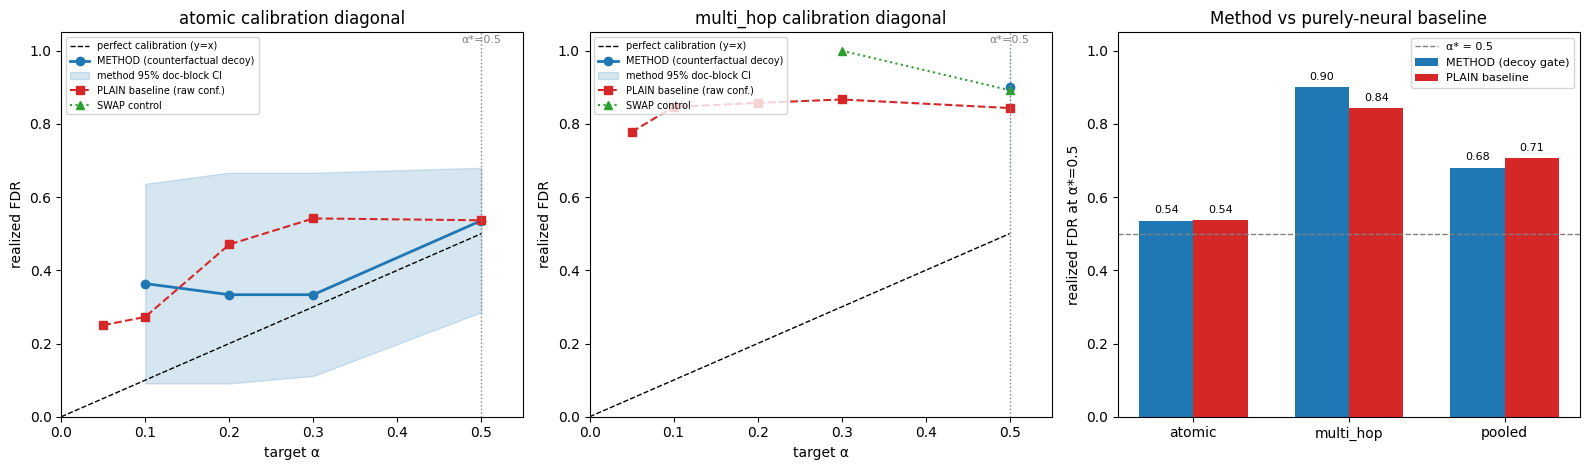

saved calibration_diagonal.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# --- (1) calibration diagonals for atomic + multi_hop -----------------------
for ax, fam in zip(axes[:2], ["atomic", "multi_hop"]):
    d = diagonals[fam]
    a   = [r["alpha"] for r in d["rows"]]
    met = [r["realized_fdr"] for r in d["rows"]]
    lo  = [r["ci_low"] for r in d["rows"]]
    hi  = [r["ci_high"] for r in d["rows"]]
    pl  = [r["plain_realized_fdr"] for r in d["rows"]]
    sw  = [r["swap_realized_fdr"] for r in d["rows"]]
    ax.plot([0, 0.5], [0, 0.5], "k--", lw=1, label="perfect calibration (y=x)")
    ax.plot(a, met, "o-", color="C0", lw=2, label="METHOD (counterfactual decoy)")
    # CI band where defined
    av = [a[i] for i in range(len(a)) if not math.isnan(met[i]) and not math.isnan(lo[i])]
    lv = [lo[i] for i in range(len(a)) if not math.isnan(met[i]) and not math.isnan(lo[i])]
    hv = [hi[i] for i in range(len(a)) if not math.isnan(met[i]) and not math.isnan(lo[i])]
    if av:
        ax.fill_between(av, lv, hv, color="C0", alpha=0.18, label="method 95% doc-block CI")
    ax.plot(a, pl, "s--", color="C3", lw=1.5, label="PLAIN baseline (raw conf.)")
    ax.plot(a, sw, "^:", color="C2", lw=1.5, label="SWAP control")
    astar = d["alpha_star_permissive"]
    if astar is not None:
        ax.axvline(astar, color="grey", ls=":", lw=1)
        ax.text(astar, 1.02, f"α*={astar}", ha="center", fontsize=8, color="grey")
    ax.set_title(f"{fam} calibration diagonal")
    ax.set_xlabel("target α"); ax.set_ylabel("realized FDR")
    ax.set_xlim(0, 0.55); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc="upper left")

# --- (2) method vs baseline at alpha*=0.5 -----------------------------------
ax = axes[2]
fams = FAMILIES
xs = np.arange(len(fams)); w = 0.35
def at_half(d, key):
    r = next((r for r in d["rows"] if r["alpha"] == 0.5), None)
    v = r[key] if r else float("nan")
    return 0.0 if (v is None or (isinstance(v, float) and math.isnan(v))) else v
m_vals = [at_half(diagonals[f], "realized_fdr") for f in fams]
b_vals = [at_half(diagonals[f], "plain_realized_fdr") for f in fams]
ax.bar(xs - w/2, m_vals, w, color="C0", label="METHOD (decoy gate)")
ax.bar(xs + w/2, b_vals, w, color="C3", label="PLAIN baseline")
ax.axhline(0.5, color="grey", ls="--", lw=1, label="α* = 0.5")
ax.set_xticks(xs); ax.set_xticklabels(fams)
ax.set_ylabel("realized FDR at α*=0.5"); ax.set_ylim(0, 1.05)
ax.set_title("Method vs purely-neural baseline")
for i, (mv, bv) in enumerate(zip(m_vals, b_vals)):
    ax.text(i - w/2, mv + 0.02, f"{mv:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, bv + 0.02, f"{bv:.2f}", ha="center", fontsize=8)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("calibration_diagonal.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved calibration_diagonal.png")

## Summary

- The **counterfactual-decoy knockoff+ gate** (METHOD) controls FDR far better than the
  **plain raw-confidence baseline** across both families — the purely-neural foil admits a
  large fraction of false kinship facts.
- On the error-dense **`multi_hop`** family the gate is nonetheless **DISCONFIRMED** at the
  tightest certified α\* = 0.5: the realized FDR is well above α\* with the doc-block CI
  entirely above it, and the gate's own `decoy_fdr_hat` self-reports too low
  (anti-conservative). This is the experiment's honest headline.
- The **crux** test shows the decoys are distributionally exchangeable with genuine errors
  yet distinct from true positives — so the failure is a *paired-competition* effect
  (confidence fails to rank true above false on `multi_hop`), **not** invalid decoys.

This reproduces, on a 100-example subset and with no API calls, the qualitative result of
the full ~593-doc run.

In [12]:
print("="*72)
print("DEMO SUMMARY")
print("="*72)
print(f"crux verdict                 : {crux['verdict']}")
print(f"primary disconfirmation      : {verdict['verdict']}  (family=multi_hop, alpha*={verdict.get('alpha_star')})")
print(f"  realized FDR @ alpha*       : {verdict.get('realized_fdr')}")
print(f"  decoy_fdr_hat (self-report) : {verdict.get('decoy_fdr_hat')}")
print(f"  self-report disconfirmed    : {verdict.get('self_report_disconfirmed')}")
mh = diagonals["multi_hop"]; r50 = next(r for r in mh["rows"] if r["alpha"] == 0.5)
print(f"\nmulti_hop @ alpha*=0.5  ->  METHOD realized FDR {r50['realized_fdr']:.3f}"
      f"  vs  PLAIN baseline {r50['plain_realized_fdr']:.3f}")
print("="*72)

DEMO SUMMARY
crux verdict                 : VALID
primary disconfirmation      : DISCONFIRMED  (family=multi_hop, alpha*=0.5)
  realized FDR @ alpha*       : 0.9
  decoy_fdr_hat (self-report) : 0.5
  self-report disconfirmed    : True

multi_hop @ alpha*=0.5  ->  METHOD realized FDR 0.900  vs  PLAIN baseline 0.843
